# Heart Disease Risk Prediction: EDA on UCI Cleveland Dataset
The original Detrano et al. study compared their Cleveland algorithm against CADENZA. a Bayesian benchmark. This project extends that work using modern ML approaches.

In [24]:
import numpy as np
import pandas as pd

In [25]:
cols = ['age', 'sex', 'cp', 'trestbps','chol', 'fbs',
        'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
        'ca', 'thal', 'target']

df = pd.read_csv('../data/heart+disease/processed.cleveland.data', names=cols, na_values='?')

In [26]:
# Convert traget to binary
df['target'] = (df['target'] > 0).astype(int)


In [27]:
print(df.shape)

(303, 14)


In [28]:
print(df.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [30]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      0.994971   22.8750

In [31]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [32]:
df['target'] = (df['target'] > 0).astype(int)
print(df.target.value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [33]:
missing_values_col = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
missing_values_col

['ca', 'thal']

In [59]:
# Impute ca and thal with median
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df[['ca','thal']] = imputer.fit_transform(df[missing_values_col])

print(df.isnull().sum())
print(df.shape)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
(303, 14)


# Visualisations
## Correlation Heatmap

<Axes: >

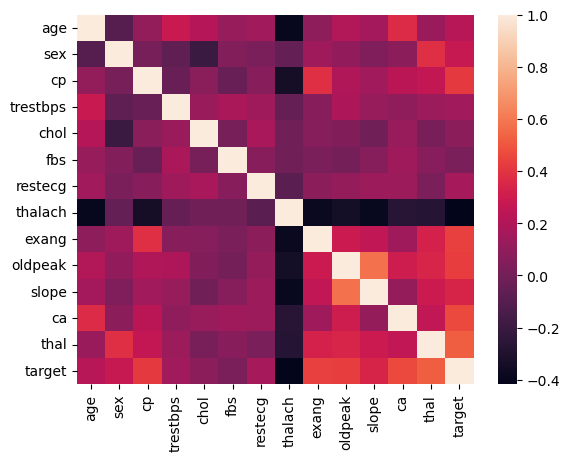

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.corr())



Features like: `thal`,`ca`,`exang`,`oldpeak`, `thalach` and `cp` are among the strong predictors for `target`, can also be understood from the `target_corr_mat` which gives descending order of absolute values of correlation.

In [42]:
corr_mat = df.corr()
target_corr_mat = corr_mat['target']

print(target_corr_mat.abs().sort_values(ascending=False))

target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64


## Distribution of `target`

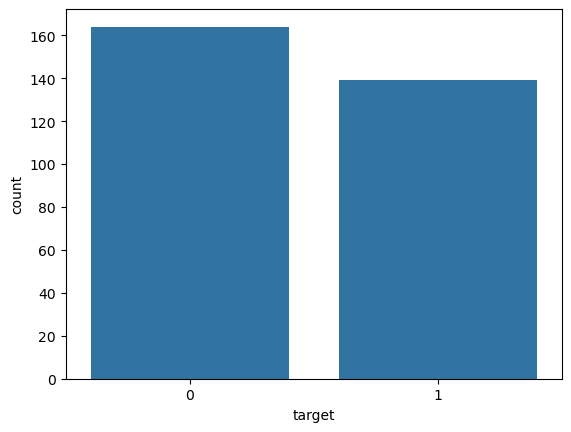

In [45]:
sns.countplot(data=df, x='target')
plt.show()

The countplot of `target` tells us that there are less number of patients with CAD than patients without CAD, which is almost balanced dataset with 54/46 split. \
This balance is actually somewhat unusual for medical datasets — many real-world clinical datasets are heavily imbalanced (e.g. 95% healthy, 5% sick). The Cleveland dataset is relatively balanced because patients were specifically referred for cardiac testing, meaning they already had some suspicion of CAD — so it's not a random population sample.

## Distribution of `age` grouped by `target`

<Axes: xlabel='age', ylabel='Count'>

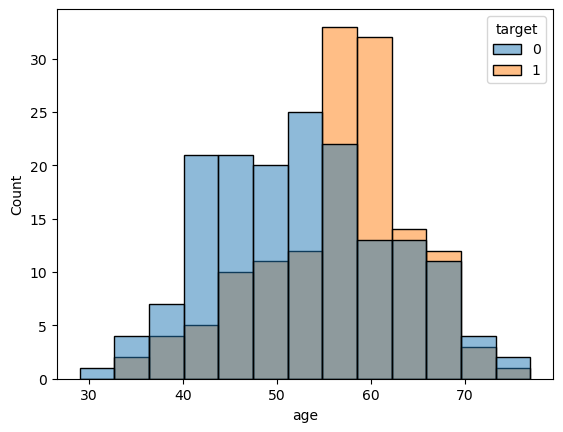

In [46]:
sns.histplot(data=df, x='age', hue='target')

The patients with `50 < age < 70` have CAD than any other ages of patient. The graph is slightly left skewed. CAD is rare below age 45, alogns with clinical knowledge. From correlation vector of `target` shows correlation of 0.22 with `age` but this plot shows that relationship is non-linear.

## Numerical Feature Analysis

In [50]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

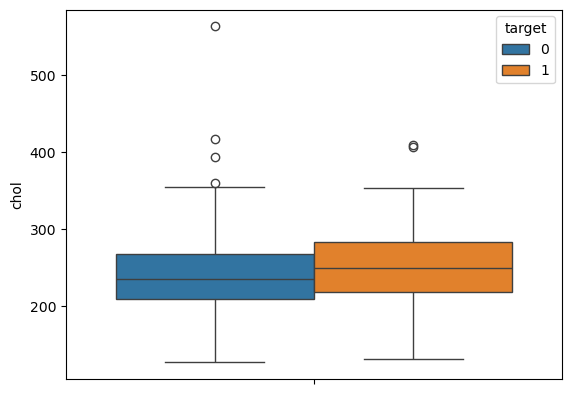

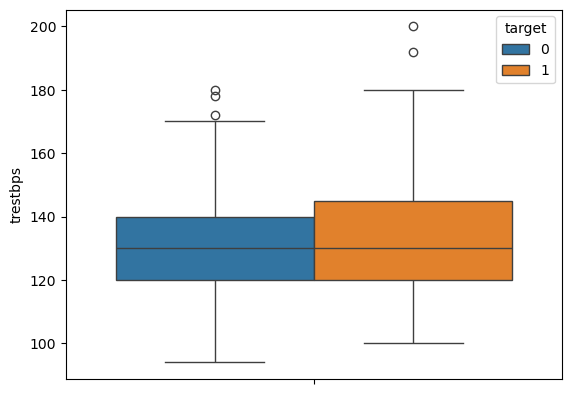

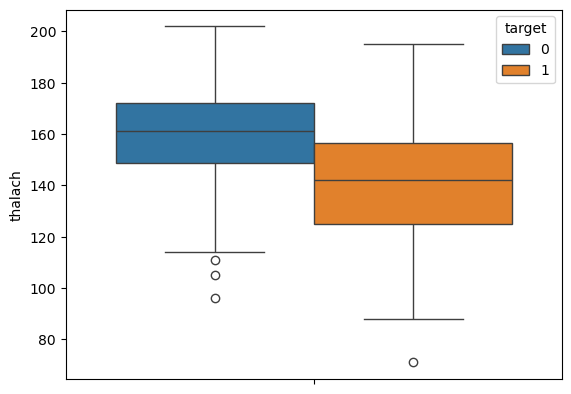

In [58]:
num_features = ['chol','trestbps','thalach']

for col in num_features:
    sns.boxplot(data=df,y=col,hue='target')
    plt.show()

- Outliers are present in the features at different positions. `chol` and `trestbps` have outliers above the max value whereas `thalach` outliers lie below the min value. 
- For `chol` and `thalach` the median don't align between the groups but for `trestbps` the median does align for both groups. 
- But since the boxes for `chol` and `trestbps` heavily overlap confirms the weak correlation
- `thalach` comes out to be strongest of 3 features.

## Categorical Feature Analysis
For `sex`, male and female are encoded as binary variable.
- value 1: male
- value 0: female

For `cp`, 
- value 1: typical angina
- value 2: atypical angina
- value 3: non-anginal pain
- value 4: asymptomatic

For `fbs`: fasting blood sugar > 120 mg/dl
- value 1: True
- value 0: False

For `exang`: exercise induced angina
- value 1: yes
- value 0: no

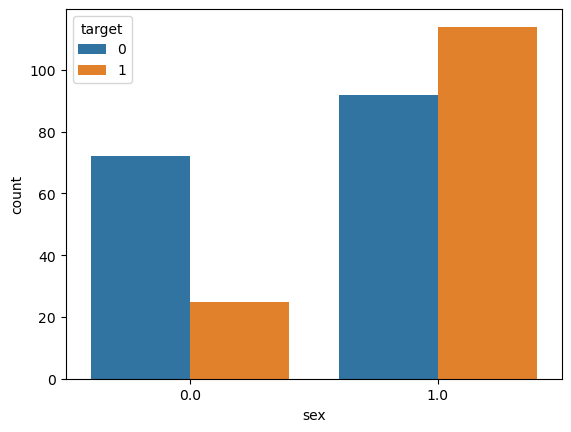

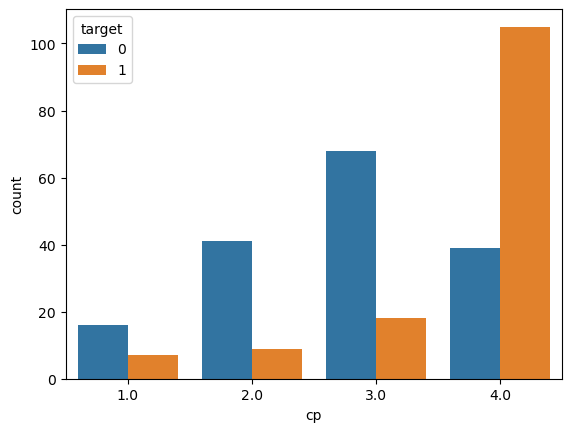

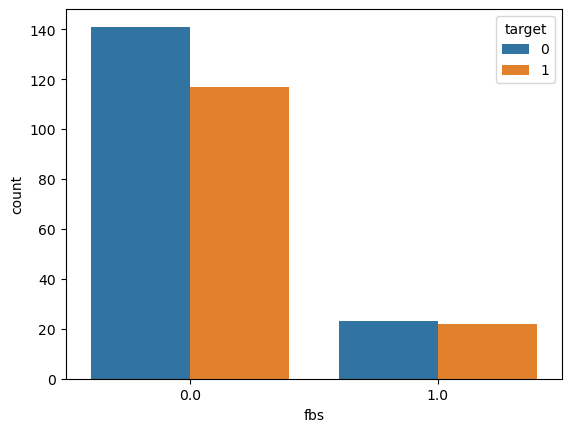

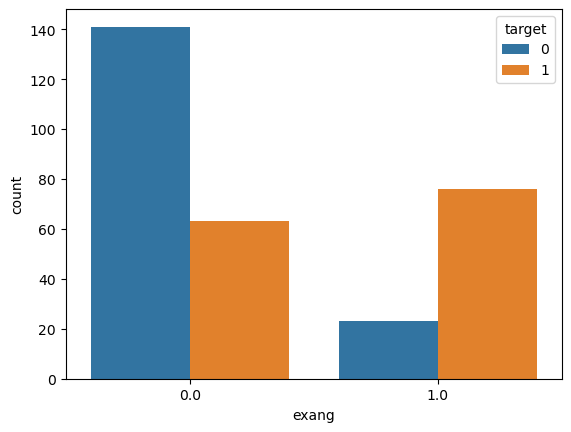

In [53]:
cat_var = ['sex','cp','fbs','exang']

for col in cat_var:
    sns.countplot(data=df,x=col,hue='target')
    plt.show()

**`sex`**: The dataset is male-dominated (~206 male, ~97 female). Among female 
patients, the majority do not have CAD (72 vs 25). In contrast, among male 
patients, CAD is more prevalent than no CAD (114 vs 93). This suggests sex 
is a meaningful predictor of CAD in this dataset.

**`cp`** (chest pain type): Most CAD patients are asymptomatic (cp=4), which 
is counterintuitive but clinically well-known — many CAD patients experience 
no chest pain at all. For cp=1,2,3 (typical angina, atypical angina, 
non-anginal pain), non-CAD patients dominate. The number of CAD patients 
increases sharply at cp=4, suggesting asymptomatic presentation is a strong 
indicator of CAD.

**`fbs`** (fasting blood sugar): The majority of patients have normal fasting 
blood sugar (fbs=0). Among this group, CAD (~118) and no CAD (~141) are 
relatively close. Very few patients have elevated fasting blood sugar (fbs=1), 
and the split is nearly equal between CAD and no CAD. This confirms the weak 
correlation (0.025) observed in the heatmap — fbs is a poor predictor of CAD.

**`exang`** (exercise induced angina): Among patients with no exercise induced 
angina (exang=0), the majority do not have CAD (141 vs 64). However, among 
patients who experience exercise induced angina (exang=1), CAD is the dominant 
diagnosis (76 vs 23). This makes clinical sense — chest pain triggered by 
physical exertion is a classic symptom of restricted blood flow due to CAD, 
confirming `exang` as a strong predictor, consistent with its correlation of 
0.43 observed in the heatmap.